# 🏅 120 Years of Olympic History — Exploratory Data Analysis
**Dataset:** [Kaggle – heesoo37](https://www.kaggle.com/datasets/heesoo37/120-years-of-olympic-history-athletes-and-results)

This notebook covers:
1. Import & Setup
2. Loading & Inspecting Data
3. Data Preprocessing
4. Univariate Analysis
5. Bivariate / Multivariate Analysis
6. Country-wise Analysis
7. Athlete Performance Analysis
8. Sport-wise Analysis
9. Year / Trend Analysis
10. Export Cleaned Data

## 1️⃣ Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Olympic colour palette
OLYMPIC_COLORS = ['#0085C7', '#F4C300', '#009F3D', '#DF0024', '#000000']
sns.set_palette(OLYMPIC_COLORS)
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.family'] = 'DejaVu Sans'
print('✅ Libraries imported successfully')

✅ Libraries imported successfully


## 2️⃣ Load Data

In [3]:
# ── Download dataset directly via Kaggle API ──────────────────────────────
# Pre-requisite: pip install kaggle
# Place your kaggle.json in ~/.kaggle/kaggle.json  (get it from kaggle.com → Account → API)

import os
import zipfile

# Download the dataset
os.system('kaggle datasets download -d heesoo37/120-years-of-olympic-history-athletes-and-results')

# Unzip
with zipfile.ZipFile('120-years-of-olympic-history-athletes-and-results.zip', 'r') as z:
    z.extractall('.')
    print('Extracted:', z.namelist())

# Load
df      = pd.read_csv('athlete_events.csv')
regions = pd.read_csv('noc_regions.csv')

print('athlete_events shape:', df.shape)
print('noc_regions shape   :', regions.shape)
df.head()

Extracted: ['athlete_events.csv', 'noc_regions.csv']
athlete_events shape: (271116, 15)
noc_regions shape   : (230, 3)


,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN


In [4]:
print('\n--- Column dtypes ---')
print(df.dtypes)
print('\n--- Basic info ---')
df.info()


--- Column dtypes ---
ID          int64
Name       object
Sex        object
Age       float64
Height    float64
Weight    float64
Team       object
NOC        object
Games      object
Year        int64
Season     object
City       object
Sport      object
Event      object
Medal      object
dtype: object

--- Basic info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271116 entries, 0 to 271115
Data columns (total 15 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   ID      271116 non-null  int64  
 1   Name    271116 non-null  object 
 2   Sex     271116 non-null  object 
 3   Age     261642 non-null  float64
 4   Height  210945 non-null  float64
 5   Weight  208241 non-null  float64
 6   Team    271116 non-null  object 
 7   NOC     271116 non-null  object 
 8   Games   271116 non-null  object 
 9   Year    271116 non-null  int64  
 10  Season  271116 non-null  object 
 11  City    271116 non-null  object 
 12  Sport   271116 non-null  

## 3️⃣ Data Preprocessing

In [5]:
# --- Missing values ---
missing = df.isnull().sum().reset_index()
missing.columns = ['Column', 'Missing Count']
missing['Missing %'] = (missing['Missing Count'] / len(df) * 100).round(2)
missing[missing['Missing Count'] > 0].sort_values('Missing %', ascending=False)

,Column,Missing Count,Missing %
14,Medal,231333,85.33
5,Weight,62875,23.19
4,Height,60171,22.19
3,Age,9474,3.49


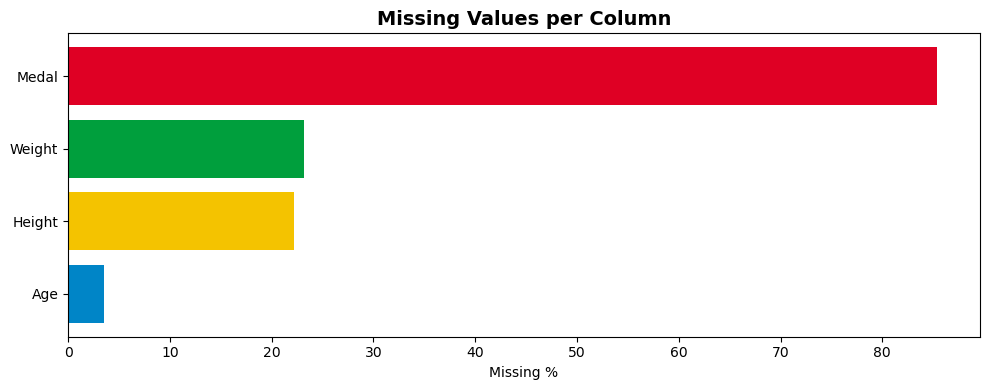

In [6]:
# Visualise missing values
fig, ax = plt.subplots(figsize=(10, 4))
miss_cols = missing[missing['Missing Count'] > 0]
ax.barh(miss_cols['Column'], miss_cols['Missing %'], color=OLYMPIC_COLORS[:len(miss_cols)])
ax.set_xlabel('Missing %')
ax.set_title('Missing Values per Column', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [7]:
# --- Merge with region ---
df = df.merge(regions[['NOC', 'region']], on='NOC', how='left')

# Fill missing Medal as 'No Medal'
df['Medal'].fillna('No Medal', inplace=True)

# Fill numeric cols with median
for col in ['Age', 'Height', 'Weight']:
    df[col].fillna(df[col].median(), inplace=True)

# Binary medal flag
df['Medal_Won'] = df['Medal'].apply(lambda x: 0 if x == 'No Medal' else 1)

# Season flag
df['Season_Flag'] = df['Season'].map({'Summer': 1, 'Winter': 0})

print('Preprocessing done. Shape:', df.shape)
df.head(3)

Preprocessing done. Shape: (271116, 18)


,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,region,Medal_Won,Season_Flag
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,No Medal,China,0,1
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,No Medal,China,0,1
2,3,Gunnar Nielsen Aaby,M,24.0,175.0,70.0,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,No Medal,Denmark,0,1


In [8]:
# Duplicates
print('Duplicate rows:', df.duplicated().sum())
df.drop_duplicates(inplace=True)
print('Shape after dropping duplicates:', df.shape)

Duplicate rows: 1385
Shape after dropping duplicates: (269731, 18)


In [9]:
# Statistical summary
df[['Age','Height','Weight']].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,269731.0,25.404536,6.062324,10.0,22.0,24.0,28.0,97.0
Height,269731.0,175.265046,9.302366,127.0,170.0,175.0,180.0,226.0
Weight,269731.0,70.541699,12.610136,25.0,63.0,70.0,76.0,214.0


## 4️⃣ Univariate Analysis

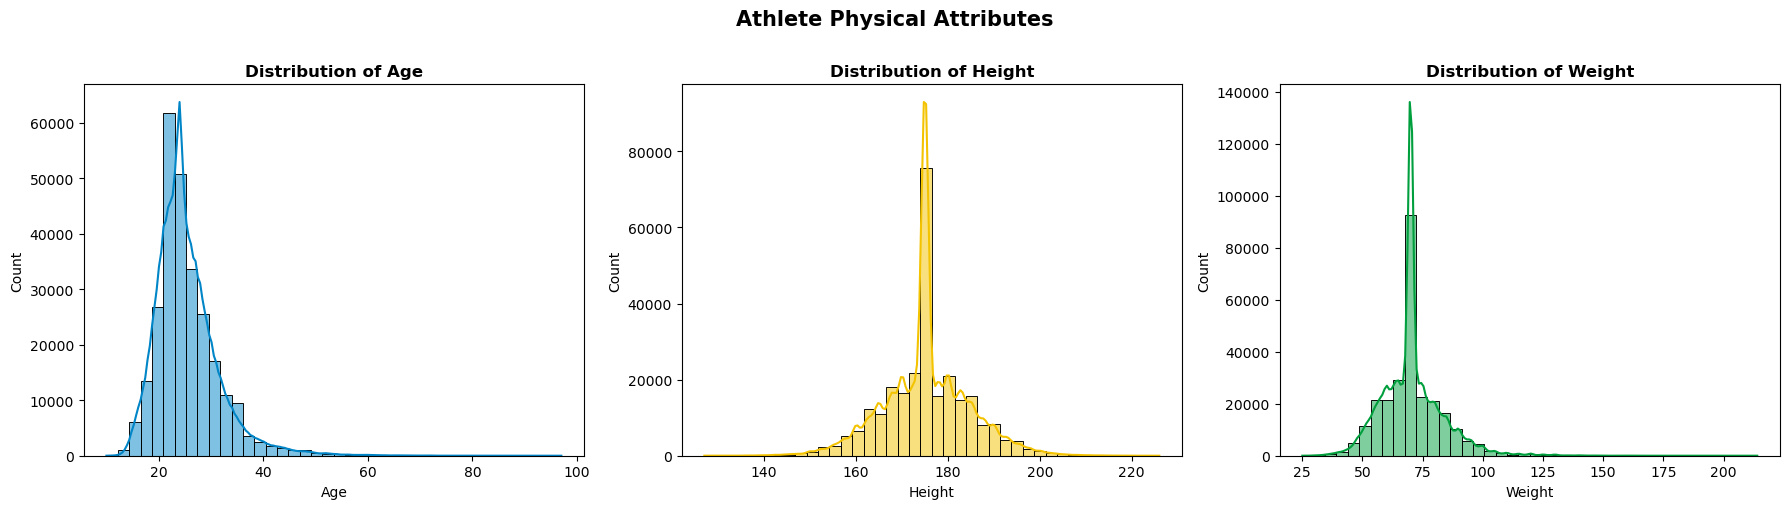

In [10]:
# Distribution of Age, Height, Weight
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col, color in zip(axes, ['Age', 'Height', 'Weight'], OLYMPIC_COLORS[:3]):
    sns.histplot(df[col].dropna(), kde=True, ax=ax, color=color, bins=40)
    ax.set_title(f'Distribution of {col}', fontweight='bold')
plt.suptitle('Athlete Physical Attributes', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

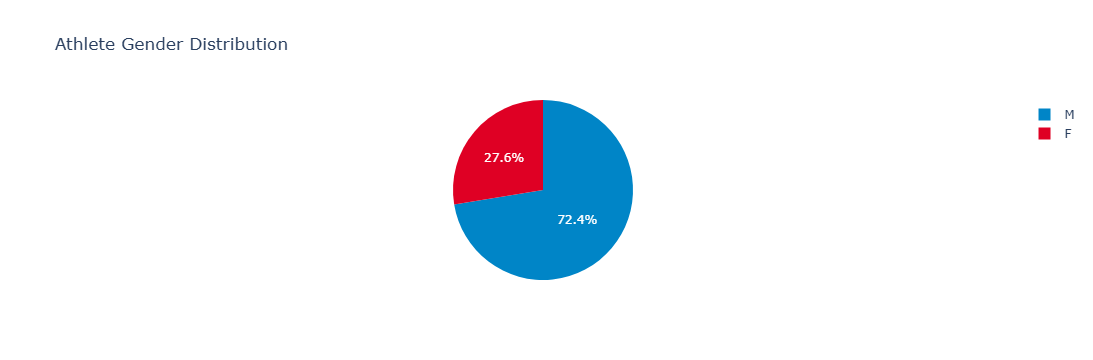

In [11]:
# Sex distribution
sex_counts = df['Sex'].value_counts()
fig = px.pie(values=sex_counts.values, names=sex_counts.index,
             title='Athlete Gender Distribution',
             color_discrete_sequence=['#0085C7','#DF0024'])
fig.show()

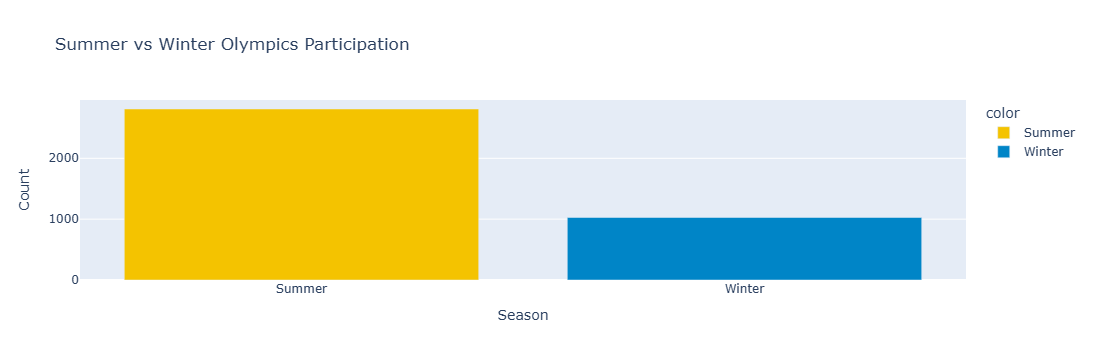

In [12]:
# Summer vs Winter
season_counts = df.drop_duplicates(subset=['Games','NOC'])['Season'].value_counts()
fig = px.bar(x=season_counts.index, y=season_counts.values,
             title='Summer vs Winter Olympics Participation',
             labels={'x':'Season','y':'Count'},
             color=season_counts.index,
             color_discrete_sequence=['#F4C300','#0085C7'])
fig.show()

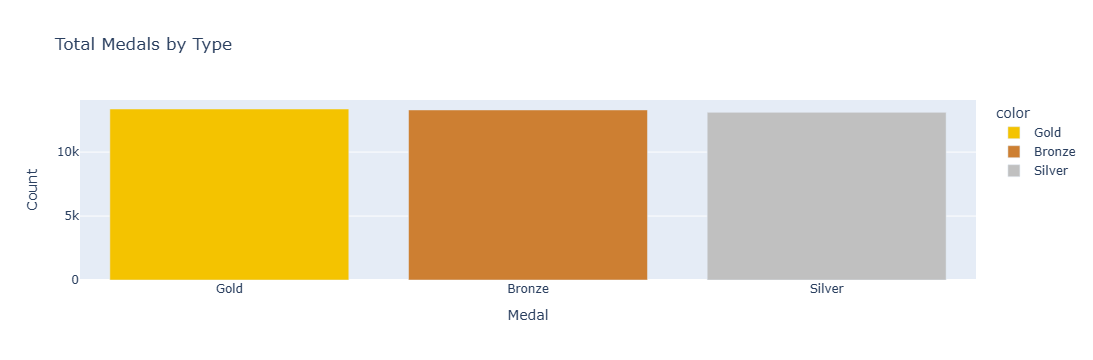

In [13]:
# Medal distribution
medal_counts = df[df['Medal'] != 'No Medal']['Medal'].value_counts()
medal_colors = {'Gold':'#F4C300','Silver':'#C0C0C0','Bronze':'#CD7F32'}
fig = px.bar(x=medal_counts.index, y=medal_counts.values,
             title='Total Medals by Type',
             labels={'x':'Medal','y':'Count'},
             color=medal_counts.index,
             color_discrete_map=medal_colors)
fig.show()

## 5️⃣ Bivariate / Multivariate Analysis

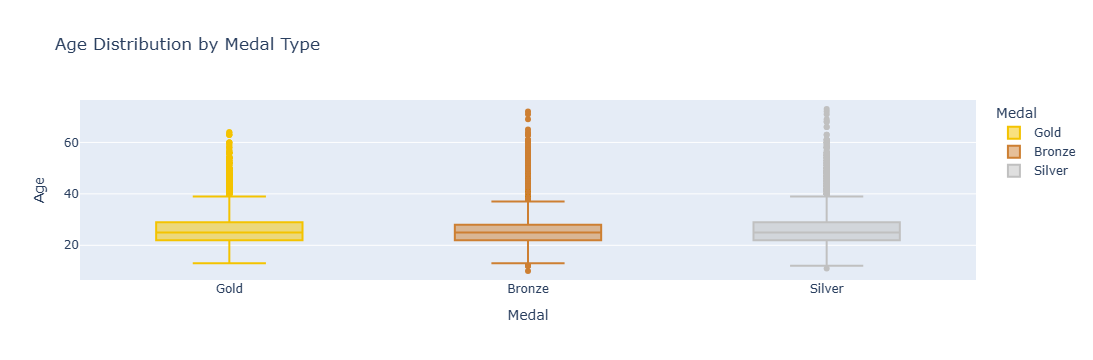

In [14]:
# Age vs Medal type
medal_df = df[df['Medal'] != 'No Medal']
fig = px.box(medal_df, x='Medal', y='Age', color='Medal',
             title='Age Distribution by Medal Type',
             color_discrete_map=medal_colors)
fig.show()

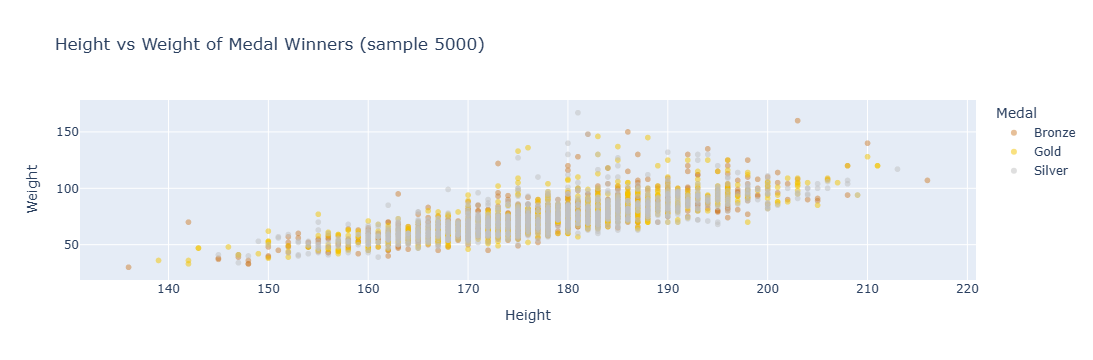

In [15]:
# Height vs Weight scatter (medal winners)
fig = px.scatter(medal_df.sample(5000, random_state=42), x='Height', y='Weight',
                 color='Medal', opacity=0.5,
                 title='Height vs Weight of Medal Winners (sample 5000)',
                 color_discrete_map=medal_colors)
fig.show()

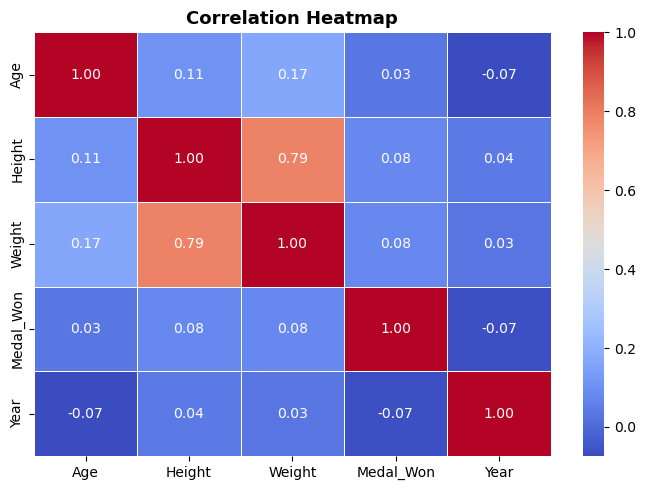

In [17]:
# Correlation heatmap
corr = df[['Age','Height','Weight','Medal_Won','Year']].corr()
fig, ax = plt.subplots(figsize=(7,5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=ax, linewidths=0.5)
ax.set_title('Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 6️⃣ Country-wise Analysis

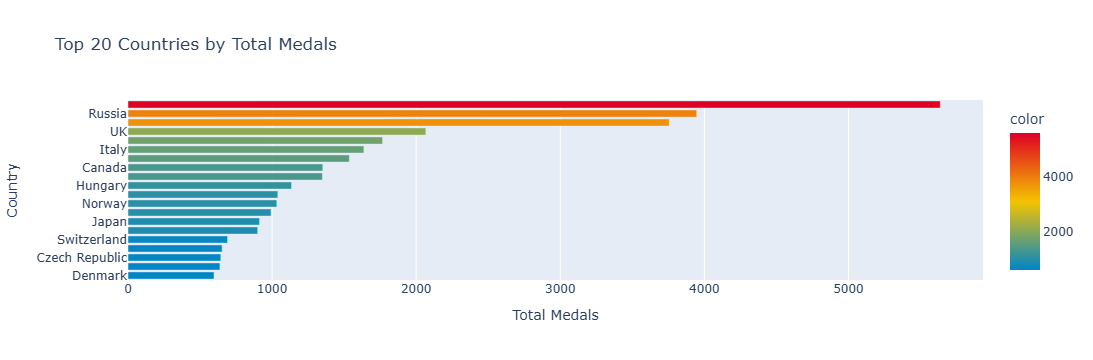

In [18]:
# Top 20 countries by total medals
top_countries = (df[df['Medal'] != 'No Medal']
                 .groupby('region')['Medal'].count()
                 .sort_values(ascending=False).head(20))

fig = px.bar(x=top_countries.values, y=top_countries.index,
             orientation='h',
             title='Top 20 Countries by Total Medals',
             labels={'x':'Total Medals','y':'Country'},
             color=top_countries.values,
             color_continuous_scale=['#0085C7','#F4C300','#DF0024'])
fig.update_layout(yaxis={'categoryorder':'total ascending'})
fig.show()

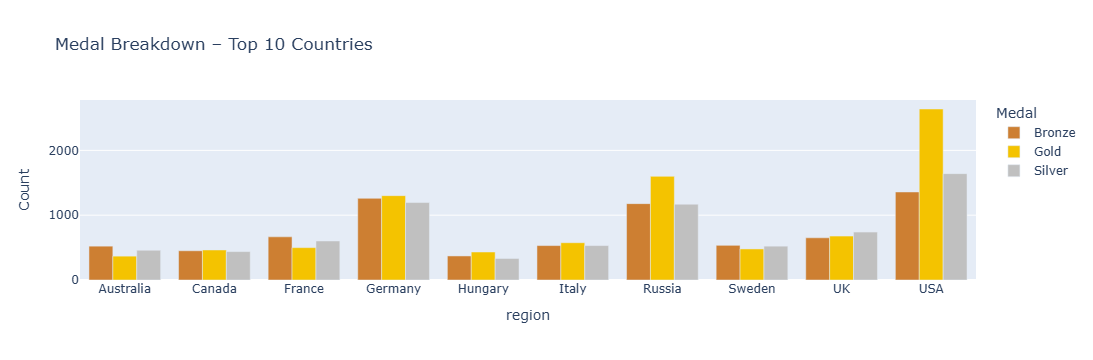

In [19]:
# Medal breakdown (Gold/Silver/Bronze) for top 10 countries
top10 = top_countries.head(10).index.tolist()
medal_breakdown = (df[(df['Medal'] != 'No Medal') & (df['region'].isin(top10))]
                   .groupby(['region','Medal']).size().reset_index(name='Count'))

fig = px.bar(medal_breakdown, x='region', y='Count', color='Medal',
             barmode='group',
             title='Medal Breakdown – Top 10 Countries',
             color_discrete_map=medal_colors)
fig.show()

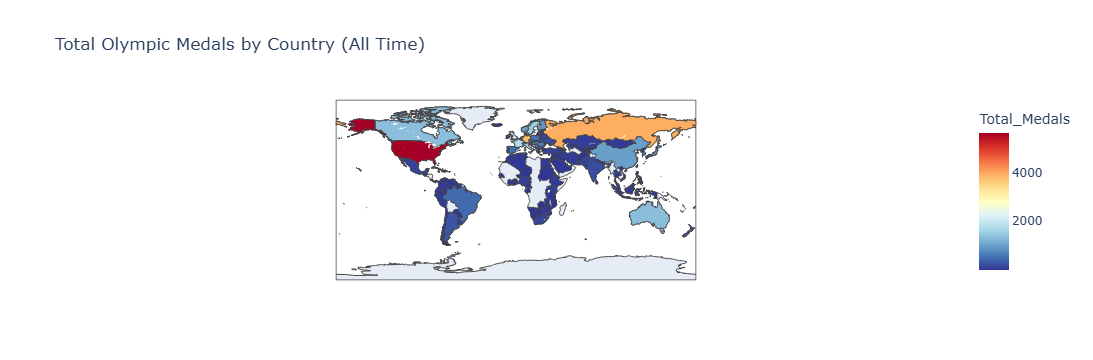

In [20]:
# Choropleth world map
country_medals = (df[df['Medal'] != 'No Medal']
                  .groupby('region')['Medal'].count().reset_index())
country_medals.columns = ['Country','Total_Medals']

fig = px.choropleth(country_medals, locations='Country',
                    locationmode='country names',
                    color='Total_Medals',
                    title='Total Olympic Medals by Country (All Time)',
                    color_continuous_scale='RdYlBu_r')
fig.show()

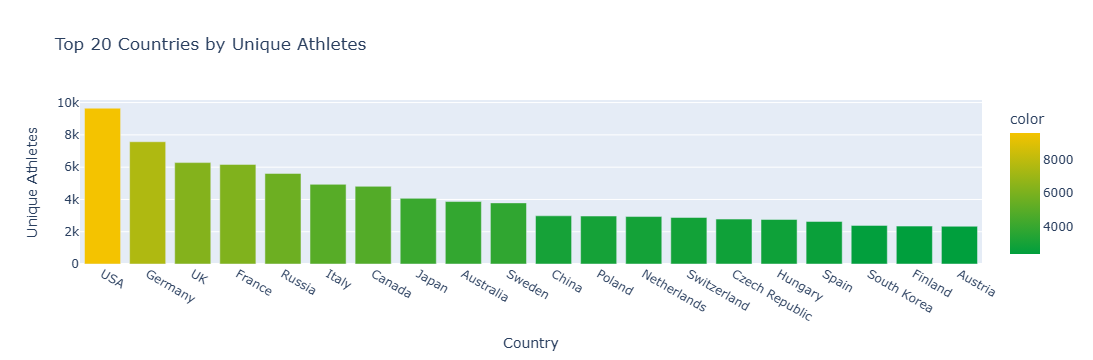

In [21]:
# Participation (unique athletes) by country
participation = df.groupby('region')['ID'].nunique().sort_values(ascending=False).head(20)
fig = px.bar(x=participation.index, y=participation.values,
             title='Top 20 Countries by Unique Athletes',
             labels={'x':'Country','y':'Unique Athletes'},
             color=participation.values,
             color_continuous_scale=['#009F3D','#F4C300'])
fig.show()

## 7️⃣ Athlete Performance Analysis

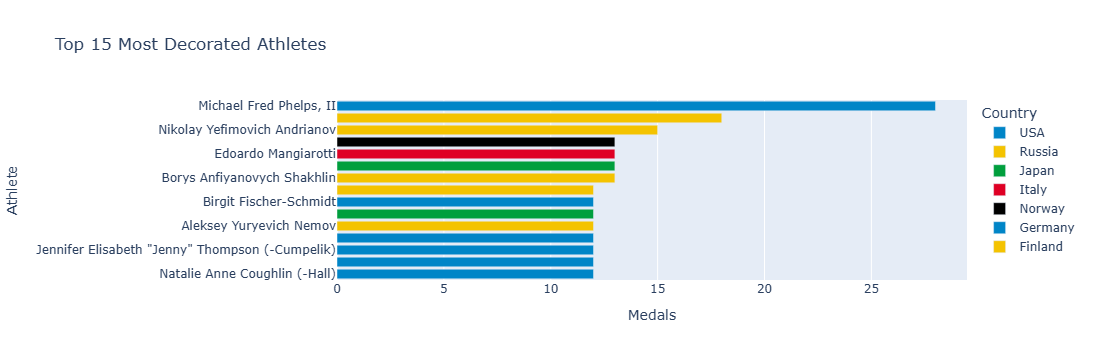

In [22]:
# Most decorated athletes (most medals)
top_athletes = (df[df['Medal'] != 'No Medal']
                .groupby(['Name','region'])['Medal'].count()
                .sort_values(ascending=False).head(15).reset_index())
top_athletes.columns = ['Athlete','Country','Medals']

fig = px.bar(top_athletes, x='Medals', y='Athlete', orientation='h',
             color='Country', title='Top 15 Most Decorated Athletes',
             color_discrete_sequence=OLYMPIC_COLORS)
fig.update_layout(yaxis={'categoryorder':'total ascending'})
fig.show()

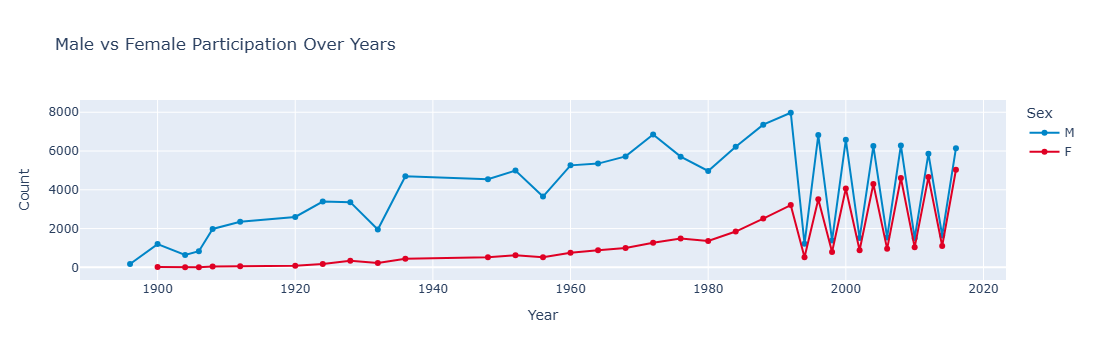

In [23]:
# Gender participation over years
gender_year = df.groupby(['Year','Sex'])['ID'].nunique().reset_index()
gender_year.columns = ['Year','Sex','Count']

fig = px.line(gender_year, x='Year', y='Count', color='Sex',
              title='Male vs Female Participation Over Years',
              color_discrete_map={'M':'#0085C7','F':'#DF0024'},
              markers=True)
fig.show()

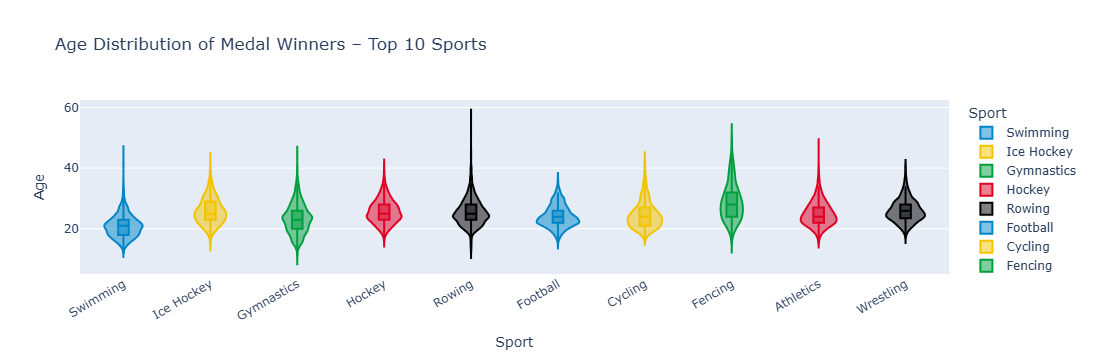

In [24]:
# Age of medal winners by sport (top 10 sports)
top_sports = df[df['Medal'] != 'No Medal']['Sport'].value_counts().head(10).index
sport_age = df[(df['Medal'] != 'No Medal') & (df['Sport'].isin(top_sports))]

fig = px.violin(sport_age, x='Sport', y='Age', color='Sport',
                box=True, points=False,
                title='Age Distribution of Medal Winners – Top 10 Sports',
                color_discrete_sequence=OLYMPIC_COLORS * 2)
fig.update_layout(xaxis_tickangle=-30)
fig.show()

## 8️⃣ Sport-wise Analysis

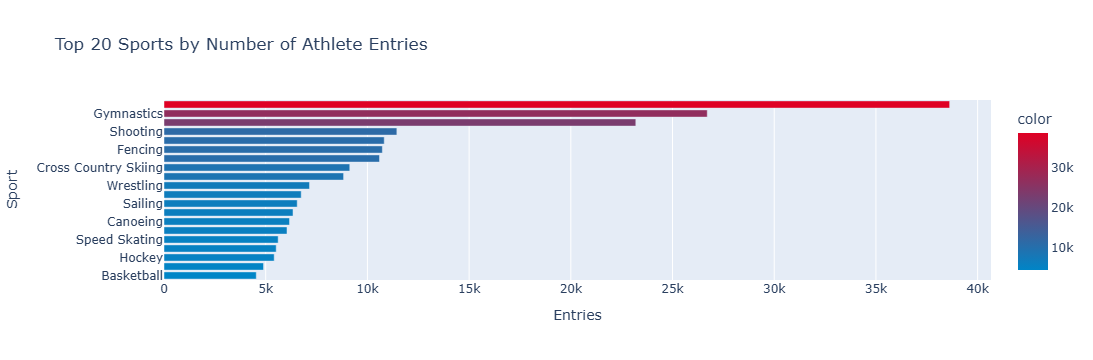

In [25]:
# Top 20 sports by total events
sport_events = df['Sport'].value_counts().head(20)

fig = px.bar(x=sport_events.values, y=sport_events.index,
             orientation='h',
             title='Top 20 Sports by Number of Athlete Entries',
             labels={'x':'Entries','y':'Sport'},
             color=sport_events.values,
             color_continuous_scale=['#0085C7','#DF0024'])
fig.update_layout(yaxis={'categoryorder':'total ascending'})
fig.show()

Only Summer sports : 49
Only Winter sports : 14
In both seasons    : 3 — {'Ice Hockey', 'Alpinism', 'Figure Skating'}


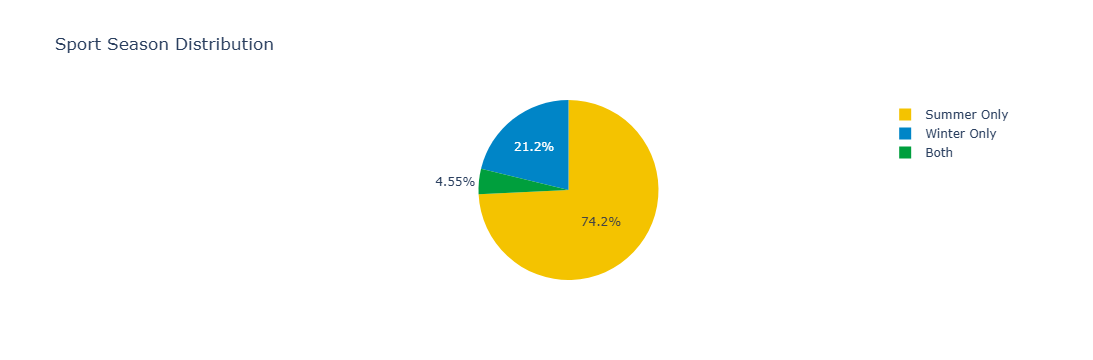

In [26]:
# Sports unique to Summer / Winter
summer_sports = set(df[df['Season']=='Summer']['Sport'].unique())
winter_sports = set(df[df['Season']=='Winter']['Sport'].unique())
only_summer = summer_sports - winter_sports
only_winter = winter_sports - summer_sports
both = summer_sports & winter_sports

print(f'Only Summer sports : {len(only_summer)}')
print(f'Only Winter sports : {len(only_winter)}')
print(f'In both seasons    : {len(both)} — {both}')

fig = px.pie(values=[len(only_summer), len(only_winter), len(both)],
             names=['Summer Only','Winter Only','Both'],
             title='Sport Season Distribution',
             color_discrete_sequence=['#F4C300','#0085C7','#009F3D'])
fig.show()

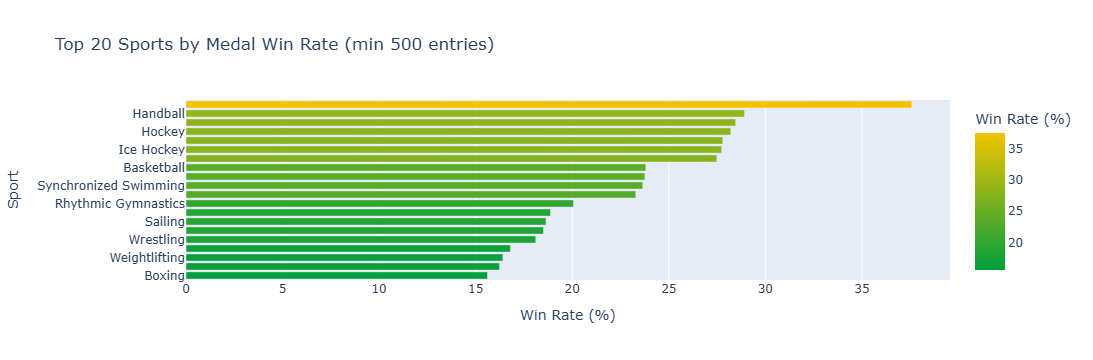

In [27]:
# Medal win rate per sport (min 500 entries)
sport_rate = (df.groupby('Sport').agg(Total=('ID','count'), Won=('Medal_Won','sum'))
              .query('Total >= 500')
              .assign(WinRate=lambda x: x['Won']/x['Total']*100)
              .sort_values('WinRate', ascending=False).head(20))

fig = px.bar(sport_rate, x='WinRate', y=sport_rate.index,
             orientation='h',
             title='Top 20 Sports by Medal Win Rate (min 500 entries)',
             labels={'WinRate':'Win Rate (%)','y':'Sport'},
             color='WinRate',
             color_continuous_scale=['#009F3D','#F4C300'])
fig.update_layout(yaxis={'categoryorder':'total ascending'})
fig.show()

## 9️⃣ Year / Trend Analysis

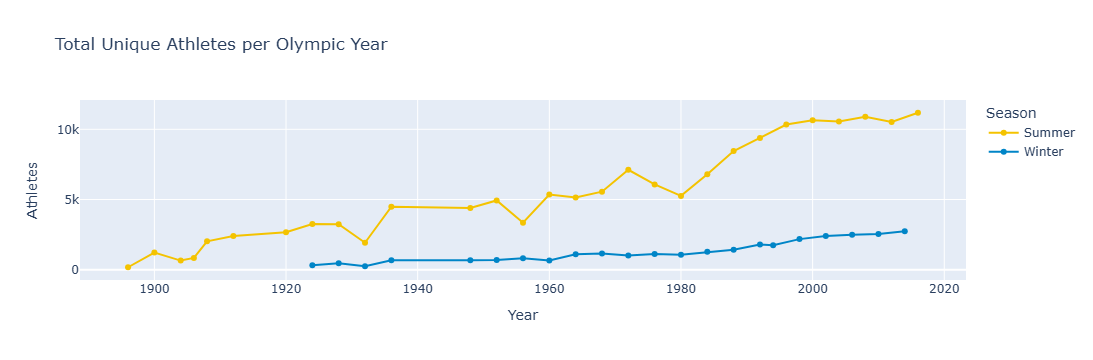

In [28]:
# Total athletes per year
athletes_year = df.groupby(['Year','Season'])['ID'].nunique().reset_index()
athletes_year.columns = ['Year','Season','Athletes']

fig = px.line(athletes_year, x='Year', y='Athletes', color='Season',
              title='Total Unique Athletes per Olympic Year',
              color_discrete_map={'Summer':'#F4C300','Winter':'#0085C7'},
              markers=True)
fig.show()

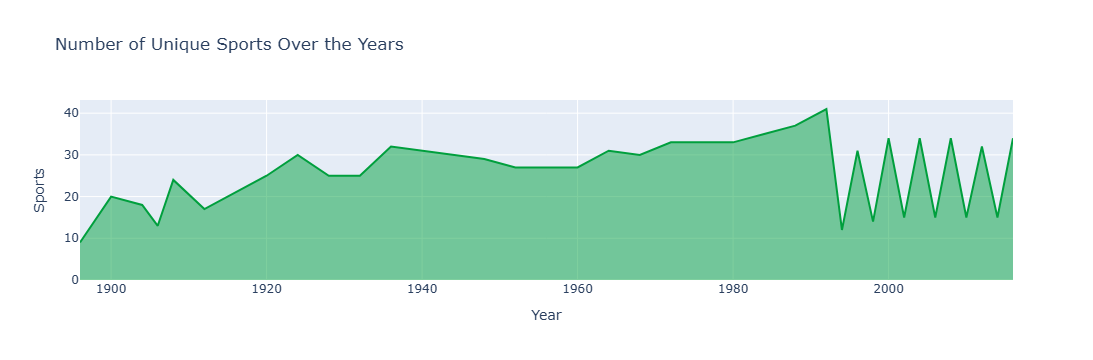

In [29]:
# Number of unique sports over the years
sports_year = df.groupby('Year')['Sport'].nunique().reset_index()
sports_year.columns = ['Year','Sports']

fig = px.area(sports_year, x='Year', y='Sports',
              title='Number of Unique Sports Over the Years',
              color_discrete_sequence=['#009F3D'])
fig.show()

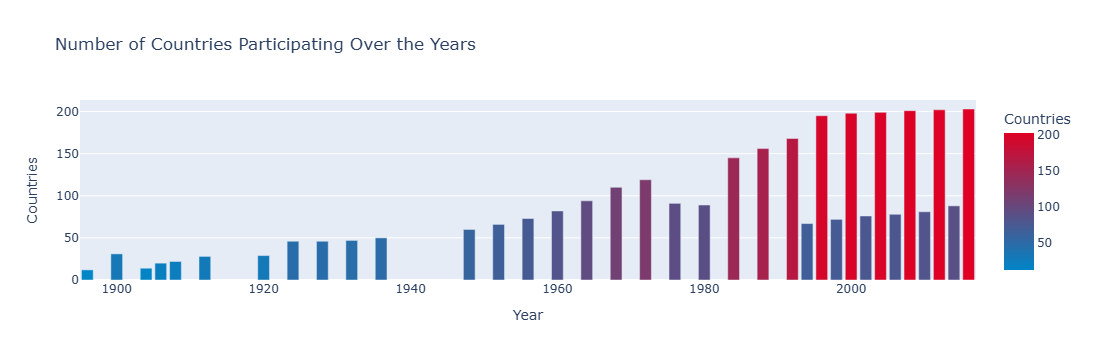

In [30]:
# Countries participating per year
countries_year = df.groupby('Year')['region'].nunique().reset_index()
countries_year.columns = ['Year','Countries']

fig = px.bar(countries_year, x='Year', y='Countries',
             title='Number of Countries Participating Over the Years',
             color='Countries',
             color_continuous_scale=['#0085C7','#DF0024'])
fig.show()

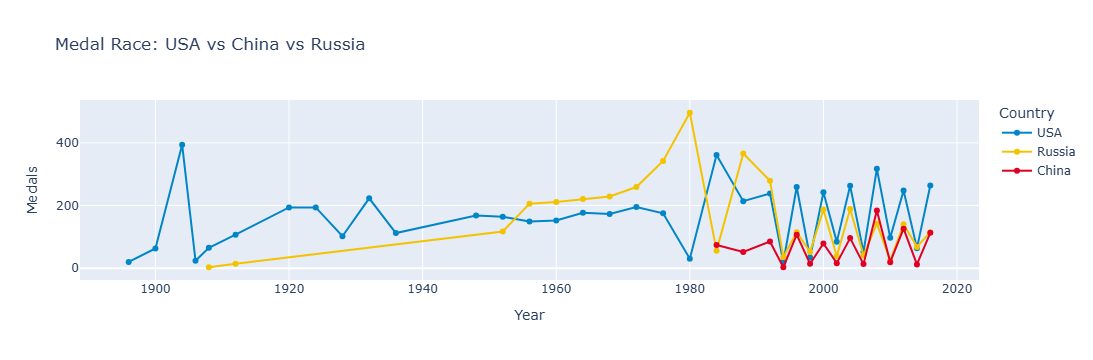

In [31]:
# USA vs CHN vs RUS medal race over years
big3 = ['USA','China','Russia']
big3_df = (df[(df['Medal'] != 'No Medal') & (df['region'].isin(big3))]
           .groupby(['Year','region'])['Medal'].count().reset_index())
big3_df.columns = ['Year','Country','Medals']

fig = px.line(big3_df, x='Year', y='Medals', color='Country',
              title='Medal Race: USA vs China vs Russia',
              color_discrete_map={'USA':'#0085C7','China':'#DF0024','Russia':'#F4C300'},
              markers=True)
fig.show()

## 🔟 Export Cleaned Data

In [32]:
df.to_csv('athlete_events_cleaned.csv', index=False)
print('✅ Cleaned data exported as athlete_events_cleaned.csv')
print('Shape:', df.shape)
df.head()

✅ Cleaned data exported as athlete_events_cleaned.csv
Shape: (269731, 18)


,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,region,Medal_Won,Season_Flag
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,No Medal,China,0,1
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,No Medal,China,0,1
2,3,Gunnar Nielsen Aaby,M,24.0,175.0,70.0,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,No Medal,Denmark,0,1
3,4,Edgar Lindenau Aabye,M,34.0,175.0,70.0,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold,Denmark,1,1
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,No Medal,Netherlands,0,0
